<a href="https://colab.research.google.com/github/SitiMutmainah15/PEMBELAJARAN-MESIN_GENAP_2026/blob/main/JS04/Tugas04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pada tahap awal dilakukan import beberapa library yang digunakan untuk proses pengolahan data, visualisasi, pembuatan model regresi, serta evaluasi hasil prediksi

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Membaca dataset

In [50]:
data = pd.read_csv("insurance.csv")

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [51]:
data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Pengecekan tipe data dan jumlah data

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Prepocessing data
Mengubah kategori menjadi angka (One Hot Encoding)

In [53]:
data = pd.get_dummies(data, drop_first=True)

data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Menentukan var fitur dan target, sleuruhnya kecuali charges

In [54]:
X = data.drop('charges', axis=1)

y = data['charges']

Dataset dibagi latih dan uji

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Melakukan normalisasi (Standar scaler) karena miliki perbedaan rentang nilai antar fitur

In [56]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Model pertama yang digunakan adalah Multiple Linear Regression (lihat hubungan antar beberapa var input thd biaya medis personal)

In [57]:
model_lr = LinearRegression()

model_lr.fit(
    X_train,
    y_train
)

LinearRegression()

In [58]:
y_pred_lr = model_lr.predict(X_test)

Evaluasi

In [59]:
r2_lr = r2_score(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

mae_lr = mean_absolute_error(y_test, y_pred_lr)


print("R2 :", r2_lr)
print("MSE :", mse_lr)
print("MAE :", mae_lr)

R2 : 0.7835929767120722
MSE : 33596915.851361476
MAE : 4181.194473753651


Nilai R-Squared menunjukan seberapa bagus model menjelaskan variasi data target, semakin mendekati nilai 1 model smeakin bisa menjelaskan hub antara var input dengan biaya medis. Untuk nilai MSE dan mAE menunjukan rata-rata kesalahan prediksi model, semakin kecil nilai kesalahan semakin rendah

Visualiasi

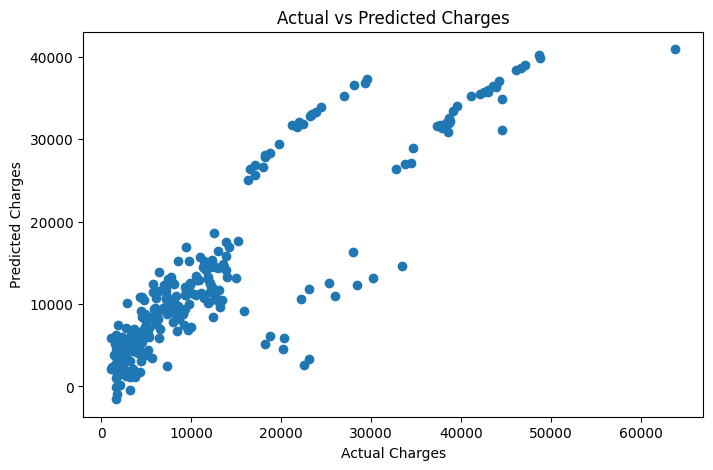

In [60]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()

Berdasarkan grafik, semakin dekat titik dengan garis diagonal maka predisi semakin mendekati nilai sebenarnya

SVR

In [61]:
model_svr = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

model_svr.fit(
    X_train,
    y_train
)

SVR(C=100)

In [62]:
y_pred_svr = model_svr.predict(X_test)

Evaluasi SVR

In [63]:
r2_svr = r2_score(y_test, y_pred_svr)

mse_svr = mean_squared_error(y_test, y_pred_svr)

mae_svr = mean_absolute_error(y_test, y_pred_svr)


print("R2 :", r2_svr)
print("MSE :", mse_svr)
print("MAE :", mae_svr)

R2 : 0.24534316665782363
MSE : 117159516.08797158
MAE : 5868.890476887904


Kesimpulan
Berdasarkan hasil evaluasi SVR, diperoleh nilai R² sebesar 0.245 dengan nilai MAE sebesar 5868.89. Hasil tersebut menunjukkan bahwa model SVR sudah mampu menangkap sebagian pola dari data biaya medis personal, walaupun masih terdapat beberapa kesalahan dalam melakukan prediksi. Jika dibandingkan dengan percobaan sebelumnya, hasil model mengalami peningkatan karena nilai R² meningkat dan nilai error menjadi lebih kecil.
Pada percobaan awal digunakan parameter default SVR dengan nilai C=1. Hasil evaluasi menunjukkan performa model masih rendah. Oleh karena itu dilakukan percobaan perubahan parameter C menjadi 100 untuk melihat pengaruhnya terhadap hasil prediksi. Setelah perubahan parameter, terjadi peningkatan nilai R² dan penurunan nilai error sehingga model memiliki performa yang lebih baik.